In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib

In [2]:
#leer archivo limpio 
df = pd.read_csv('airbnb_rio_clean.csv')

In [3]:
#explorar df
df.head()


,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_identity_verified,latitude,longitude,room_type,accommodates,bedrooms,...,has_pool,has_wifi,has_free_parking,has_ac_heating,has_kitchen,has_jacuzzi,has_washer_dryer,has_self_checkin,has_tv_cable,has_bbq
0,95,97,0.0,10.0,1.0,-22.982818,-43.222457,1.0,4,2.0,...,0,1,1,1,1,0,1,0,1,0
1,100,46,0.0,39.0,1.0,-22.984090,-43.191770,1.0,2,1.0,...,0,1,0,1,1,0,1,0,0,0
2,0,0,0.0,2.0,1.0,-22.814911,-43.379011,1.0,4,1.0,...,0,0,1,1,1,0,1,0,0,1
3,100,71,1.0,1.0,1.0,-23.010000,-43.344820,1.0,4,1.0,...,1,1,1,1,1,0,1,0,0,0
4,100,99,1.0,17.0,1.0,-22.970696,-43.186048,1.0,6,2.0,...,0,1,0,1,1,0,1,0,0,0


In [4]:
#crear variable artificial
df["recomendable"] = (df["review_scores_rating"] >= 4.6).astype(int) #Definir umbral de clasificacion
df["recomendable"].value_counts(normalize=True) * 100 # ver porcentaje de datos 


recomendable
1    69.683748
0    30.316252
Name: proportion, dtype: float64

In [5]:
bins = [0, 1, 2, 3, 4, 5]
labels = ["[0-1)", "[1-2)", "[2-3)", "[3-4)", "[4-5)"]

df["rating_range"] = pd.cut(df["review_scores_rating"], bins=bins, labels=labels, right=False)

df["rating_range"].value_counts(normalize=True).mul(100).round(2)

rating_range
[4-5)    68.62
[0-1)    29.45
[3-4)     1.37
[2-3)     0.29
[1-2)     0.28
Name: proportion, dtype: float64

## MODELO CLASIFICACION MLFLOW

In [0]:
#Escoger variables que entran

#Modelo 1
x_1=['host_response_rate', 'host_acceptance_rate', 'host_is_superhost','host_total_listings_count', 'host_identity_verified', 'latitude','longitude', 'room_type', 'accommodates', 'bedrooms', 'beds','minimum_nights', 'maximum_nights', 'maximum_minimum_nights','maximum_nights_avg_ntm', 'availability_365', 'availability_eoy','estimated_occupancy_l365d','review_scores_communication', 'review_scores_location','instant_bookable', 'bathroomsf', 'has_pool', 'has_wifi', 'has_free_parking', 'has_ac_heating', 'has_kitchen', 'has_jacuzzi','has_washer_dryer', 'has_self_checkin', 'has_tv_cable', 'has_bbq','price']
       
x_num=['host_response_rate', 'host_acceptance_rate','host_total_listings_count', 'latitude','longitude', 'accommodates', 'bedrooms', 'beds','minimum_nights', 'maximum_nights', 'maximum_minimum_nights','maximum_nights_avg_ntm', 'availability_365', 'availability_eoy','estimated_occupancy_l365d','review_scores_communication',"price", 'review_scores_location','bathroomsf']

#Modelo 2
x_2=['host_response_rate', 'host_acceptance_rate', 'host_is_superhost','host_total_listings_count', 'host_identity_verified', 'latitude','longitude', 'room_type', 'accommodates', 'bedrooms', 'beds','minimum_nights', 'maximum_nights', 'maximum_minimum_nights','maximum_nights_avg_ntm', 'availability_365', 'availability_eoy','estimated_occupancy_l365d','review_scores_communication', 'review_scores_location','instant_bookable', 'bathroomsf', 'has_pool', 'has_wifi', 'has_free_parking', 'has_ac_heating', 'has_kitchen', 'has_jacuzzi','has_washer_dryer', 'has_self_checkin', 'has_tv_cable', 'has_bbq']
       
x_num=['host_response_rate', 'host_acceptance_rate','host_total_listings_count', 'latitude','longitude', 'accommodates', 'bedrooms', 'beds','minimum_nights', 'maximum_nights', 'maximum_minimum_nights','maximum_nights_avg_ntm', 'availability_365', 'availability_eoy','estimated_occupancy_l365d','review_scores_communication', 'review_scores_location','bathroomsf']
#Modelo 3
x_3=['host_response_rate', 'host_acceptance_rate', 'host_is_superhost','host_total_listings_count', 'host_identity_verified', 'room_type', 'bedrooms', 'beds', 'maximum_minimum_nights', 'availability_365','review_scores_communication', 'review_scores_location','instant_bookable', 'bathroomsf', 'has_pool', 'has_wifi', 'has_free_parking', 'has_ac_heating', 'has_kitchen', 'has_jacuzzi','has_washer_dryer', 'has_self_checkin', 'has_tv_cable', 'has_bbq']
       
x_num=['host_response_rate', 'host_acceptance_rate','host_total_listings_count', 'bedrooms', 'beds','maximum_minimum_nights', 'availability_365', 'review_scores_communication', 'review_scores_location','bathroomsf']
#Modelo 4
x_4=['host_response_rate', 'host_is_superhost', 'host_identity_verified', 'room_type', 'bedrooms', 'beds', 'maximum_minimum_nights', 'availability_365','review_scores_communication', 'review_scores_location','instant_bookable', 'bathroomsf', 'has_pool', 'has_wifi', 'has_free_parking', 'has_ac_heating', 'has_kitchen', 'has_jacuzzi','has_washer_dryer', 'has_self_checkin', 'has_tv_cable', 'has_bbq']
       
x_num=['host_response_rate', 'bedrooms', 'beds','maximum_minimum_nights', 'availability_365', 'review_scores_communication', 'review_scores_location','bathroomsf']

#Modelo 5 (ningun amenity)
x_5=['host_response_rate', 'host_is_superhost', 'host_identity_verified', 'room_type', 'bedrooms', 'beds', 'maximum_minimum_nights', 'availability_365','review_scores_communication', 'review_scores_location','instant_bookable', 'bathroomsf']
       
x_num=['host_response_rate', 'bedrooms', 'beds','maximum_minimum_nights', 'availability_365', 'review_scores_communication', 'review_scores_location','bathroomsf']

#Modelo 6 sin otros reviews
x_6=['host_response_rate', 'host_is_superhost', 'host_identity_verified', 'room_type', 'bedrooms', 'beds', 'maximum_minimum_nights', 'availability_365','instant_bookable', 'bathroomsf']
       
x_num=['host_response_rate', 'bedrooms', 'beds','maximum_minimum_nights', 'availability_365','bathroomsf']

#Modelo 7 solo reviews
x_7=['review_scores_communication', 'review_scores_location']
       
x_num=['review_scores_communication', 'review_scores_location']

#Modelo 8 solo amenities
x_8=[ 'has_pool', 'has_wifi', 'has_free_parking', 'has_ac_heating', 'has_kitchen', 'has_jacuzzi','has_washer_dryer', 'has_self_checkin', 'has_tv_cable', 'has_bbq']   
x_num=[]

#Modelo 9 solo accionables
x_9=['host_response_rate','host_acceptance_rate','host_is_superhost','host_identity_verified','instant_bookable','minimum_nights','maximum_nights','has_wifi','has_free_parking','has_ac_heating','has_kitchen','has_jacuzzi','has_washer_dryer','has_self_checkin','has_tv_cable','has_bbq','has_pool','bathroomsf','beds']

x_num=['host_response_rate','host_acceptance_rate','minimum_nights','maximum_nights','bathroomsf','beds']

#Modelo 10 solo accionables sin amenities
x_10=['host_response_rate','host_acceptance_rate','host_is_superhost','host_identity_verified','instant_bookable','minimum_nights','maximum_nights','bathroomsf','beds']
x_num=['host_response_rate','host_acceptance_rate','minimum_nights','maximum_nights','bathroomsf','beds']

#Modelo 11 solo accionables con algunos amenities FINAL
x_11=['host_response_rate','host_is_superhost','host_identity_verified','instant_bookable','minimum_nights','maximum_nights','bathroomsf','beds', 'has_wifi','has_ac_heating','has_self_checkin','has_tv_cable']
x_num=['host_response_rate','minimum_nights','maximum_nights','bathroomsf','beds']

#Modelo 12
x_12=['host_response_rate','host_acceptance_rate','host_identity_verified','instant_bookable','minimum_nights','maximum_nights','bathroomsf','beds']
x_num=['host_response_rate','host_acceptance_rate','minimum_nights','maximum_nights','bathroomsf','beds']

#Modelo 13 solo accionables sin variables que no tienen mucho sentido
x_13=['host_response_rate','host_identity_verified','instant_bookable','minimum_nights','maximum_nights','has_wifi','has_free_parking','has_ac_heating','has_kitchen','has_jacuzzi','has_washer_dryer','has_self_checkin','has_tv_cable','has_bbq','has_pool','bathroomsf','beds']
x_num=['host_response_rate','minimum_nights','maximum_nights','bathroomsf','beds']

In [0]:
'0. Funcion para estandarizar los datos numericos solo'
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), x_num),   # escalo solo las continuas--------------->
        # las categóricas (0/1) pasan sin tocarse
    ],remainder="passthrough")

'1. Dividir test y train'
#  Definir X e y
y = df["recomendable"].copy()
X = df[x_11].copy() # CAMBIARRRRRRR---------------------------->

# 4. Dividir en train y test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True )

'2. Estandarizar x num (se asume que categoricos ya estan en dummies)'
# Ajustar el preprocesador con datos de entrenamiento
preprocesamiento.fit(X_train)

# Transformar train y test --> estandariza
X_train_proc = preprocesamiento.transform(X_train)
X_test_proc = preprocesamiento.transform(X_test)

In [0]:

# MLflow

import mlflow
import mlflow.sklearn
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

mlflow.set_registry_uri("databricks-uc")
experiment = mlflow.set_experiment("/clasificacionisabella")

with mlflow.start_run(experiment_id=experiment.experiment_id, run_name="modelo 11 FINAL"):

    # ----- Hiperparámetros -----
    params_nn = {
        "hidden_layer_sizes": (32, 16, 8),
        "activation": "relu",
        "solver": "adam",
        "learning_rate_init": 0.0005,
        "max_iter": 500,
        "random_state": 42}
    
    mlflow.log_params(params_nn)

    # ----- Modelo (CLASIFICACIÓN) ----------------------------
    nn = MLPClassifier(**params_nn)

    #  ----- entrenar usando X_train_proc y y_train (0/1) -----
    nn.fit(X_train_proc, y_train)

    #  ----- predicciones -----
    # probabilidades de clase 1
    y_proba = nn.predict_proba(X_test_proc)[:, 1]
    # predicción binaria (0/1)
    y_pred = nn.predict(X_test_proc)

    # ----- Guardar número de iteraciones ---------------------
    with open("n_iter_clasificacion.txt", "w") as f:
        f.write(str(nn.n_iter_))
    mlflow.log_artifact("n_iter_clasificacion.txt")

    # ----- Guardar loss curve -----
    plt.figure()
    plt.plot(nn.loss_curve_)
    plt.xlabel("Iteraciones")
    plt.ylabel("Loss")
    plt.title("Curva de pérdida (clasificación)")
    plt.savefig("loss_curve_clasificacion.png", bbox_inches="tight")
    plt.close()
    mlflow.log_artifact("loss_curve_clasificacion.png")

    # ----- Matriz de confusión como artifact -----
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Real 0", "Real 1"],
        columns=["Pred 0", "Pred 1"],
    )
    cm_df.to_csv("confusion_matrix.csv")
    mlflow.log_artifact("confusion_matrix.csv")

    # (Opcional) Curva ROC
    from sklearn.metrics import RocCurveDisplay
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title("Curva ROC")
    plt.savefig("roc_curve.png", bbox_inches="tight")
    plt.close()
    mlflow.log_artifact("roc_curve.png")

    # Features como artifact
    with open("features_clasificacion.txt", "w") as f:
        for col in X_train.columns:
            f.write(f"{col}\n")
    mlflow.log_artifact("features_clasificacion.txt")

    # ----- Métricas de clasificación -----
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)

    metrics = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc,
    }

    for name, value in metrics.items():
        mlflow.log_metric(name, value)
        print(f"{name.upper()}: {value}")

    # ----- Guardar modelo y preprocesador --------------------
    mlflow.sklearn.log_model(
        sk_model=nn,
        artifact_path="modelo_clasificacion_nn"
    )

    joblib.dump(preprocesamiento, "preprocesamiento_modelo_clasificacion.pkl")
    mlflow.log_artifact("preprocesamiento_modelo_clasificacion.pkl")


### MODELO SIN MLFLOW

Accuracy : 0.749
Precision: 0.787
Recall   : 0.874
F1-score : 0.828
ROC AUC  : 0.787


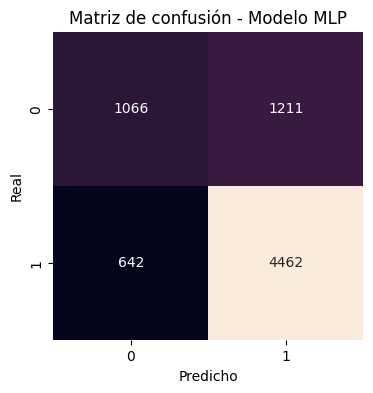

In [6]:
### Modelo sin MLFOWN

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
import joblib

#leer archivo limpio 
df = pd.read_csv('airbnb_rio_clean.csv')
#crear variable artificial
df["recomendable"] = (df["review_scores_rating"] >= 4.6).astype(int) #Definir umbral de clasificacion
df["recomendable"].value_counts(normalize=True) * 100 # ver porcentaje de datos 

#Modelo 11 solo accionables con algunos amenities FINAL
x_11=['host_response_rate','host_is_superhost','host_identity_verified','instant_bookable','minimum_nights','maximum_nights','bathroomsf','beds', 'has_wifi','has_ac_heating','has_self_checkin','has_tv_cable']
x_num=['host_response_rate','minimum_nights','maximum_nights','bathroomsf','beds']

'0. Funcion para estandarizar los datos numericos solo'
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), x_num),   # escalo solo las continuas--------------->
        # las categóricas (0/1) pasan sin tocarse
    ],remainder="passthrough")

'1. Dividir test y train'
#  Definir X e y
y = df["recomendable"].copy()
X = df[x_11].copy() # CAMBIARRRRRRR---------------------------->

# 4. Dividir en train y test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True )

'2. Estandarizar x num (se asume que categoricos ya estan en dummies)'
# Ajustar el preprocesador con datos de entrenamiento
preprocesamiento.fit(X_train)

# Transformar train y test --> estandariza
X_train_proc = preprocesamiento.transform(X_train)
X_test_proc = preprocesamiento.transform(X_test)

# -------------------------------------------------
# 1. Hiperparámetros del modelo
# -------------------------------------------------
params_nn = {
    "hidden_layer_sizes": (32, 16, 8),
    "activation": "relu",
    "solver": "adam",
    "learning_rate_init": 0.0005,
    "max_iter": 500,
    "random_state": 42,
}

# -------------------------------------------------
# 2. Definir y entrenar el modelo
# -------------------------------------------------
nn = MLPClassifier(**params_nn)

# Entrenar con los datos procesados
nn.fit(X_train_proc, y_train)

# -------------------------------------------------
# 3. Predicciones
# -------------------------------------------------
# Probabilidades de clase positiva (1)
y_proba = nn.predict_proba(X_test_proc)[:, 1]

# Predicción binaria (0/1)
y_pred = nn.predict(X_test_proc)

# -------------------------------------------------
# 4. Métricas
# -------------------------------------------------
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC AUC  : {roc_auc:.3f}")

# -------------------------------------------------
# 5. Matriz de confusión (visual)
# -------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión - Modelo MLP")
plt.show()

### VISUALIZACION

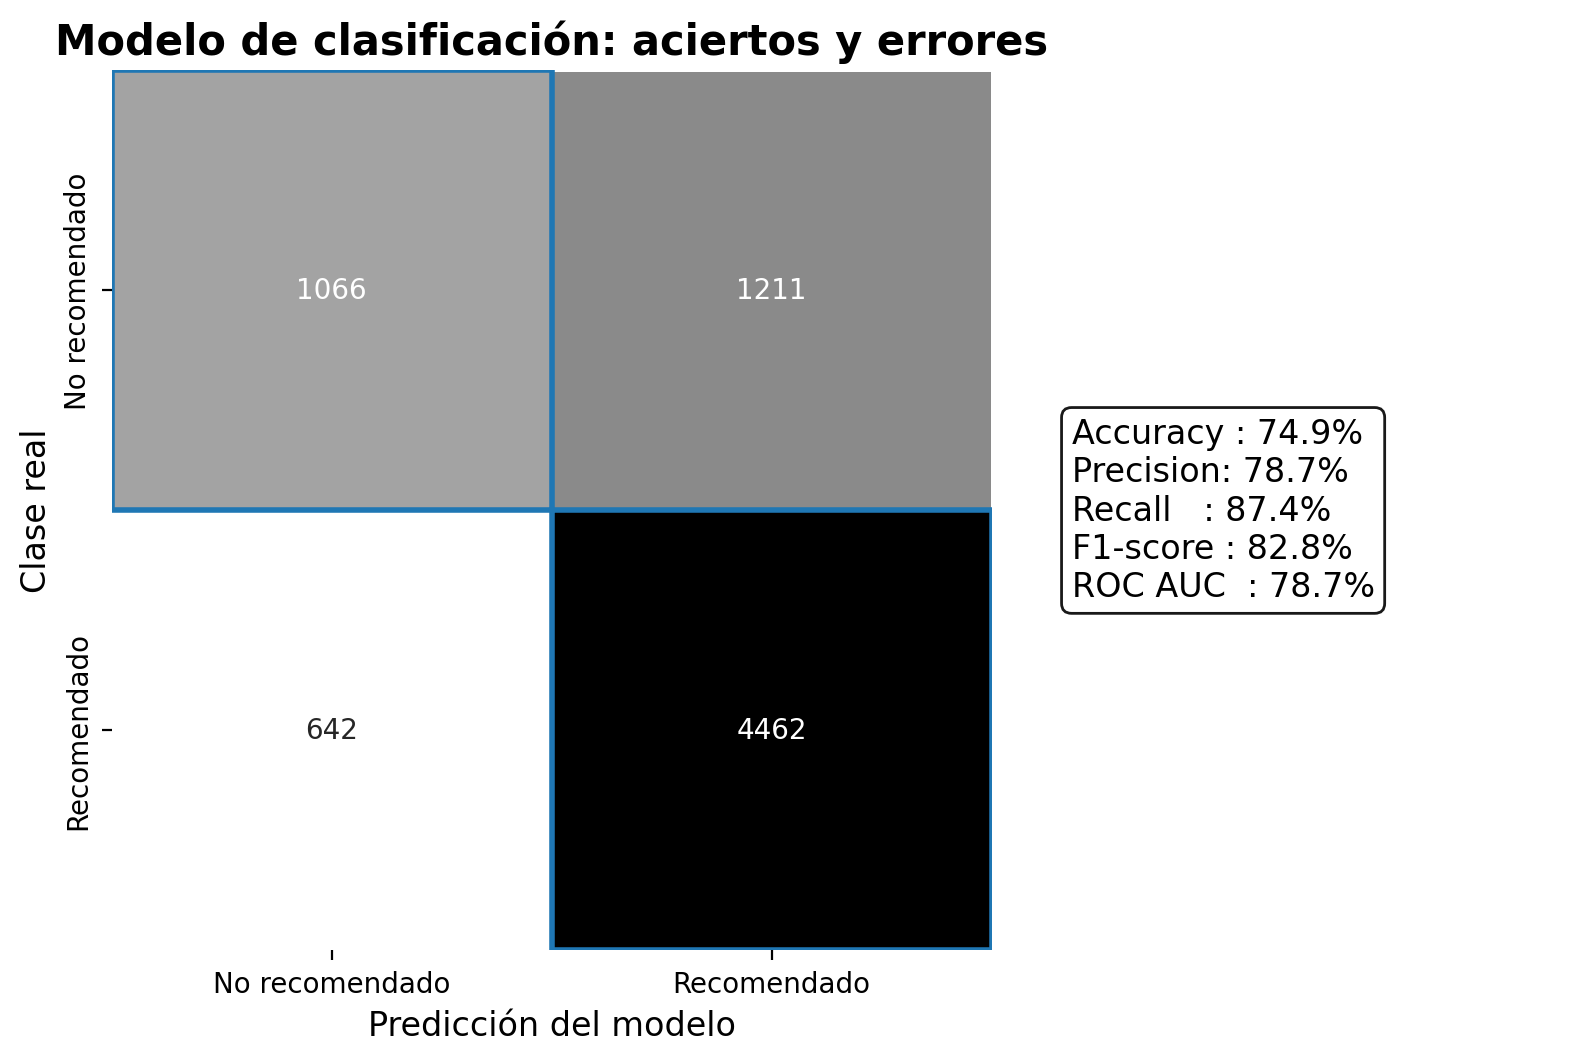

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# --- Matriz de confusión ---
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
cm_norm = cm / cm.sum(axis=1, keepdims=True)

labels_clases = ["No recomendado", "Recomendado"]

# Crear figura con dos áreas: heatmap + texto
fig = plt.figure(figsize=(8, 6), dpi=200)

# --- Subplot para la matriz (70% del ancho) ---
ax = fig.add_axes([0.05, 0.1, 0.55, 0.8])  # left, bottom, width, height

sns.heatmap(
    cm_norm,
    annot=cm,
    fmt="d",
    cmap="Greys",
    cbar=False,
    xticklabels=labels_clases,
    yticklabels=labels_clases,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    square=True  # <--- fuerza la matriz a ser cuadrada
)

ax.set_xlabel("Predicción del modelo", fontsize=12)
ax.set_ylabel("Clase real", fontsize=12)
ax.set_title("Modelo de clasificación: aciertos y errores",
             fontsize=15, weight="bold")

# Resaltar diagonal
for i in range(2):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                               edgecolor="#1f77b4", linewidth=2))

# --- Subplot para el texto (resto del espacio a la derecha) ---
ax_text = fig.add_axes([0.65, 0.25, 0.3, 0.5])
ax_text.axis("off")

texto_cls = (
    f"Accuracy : {accuracy*100:,.1f}%\n"
    f"Precision: {precision*100:,.1f}%\n"
    f"Recall   : {recall*100:,.1f}%\n"
    f"F1-score : {f1*100:,.1f}%\n"
    f"ROC AUC  : {roc_auc*100:,.1f}%"
)

ax_text.text(
    0, 0.5, texto_cls,
    ha="left", va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9)
)

plt.show()